In [7]:
import pandas as pd 

df_combined = pd.read_csv("combined_yearly.csv")
print(df_combined.columns)
# print(df_combined.head(2))
print(df_combined.shape)
# print(df_combined.describe())
print(df_combined.info())


Index(['country', 'commodity', 'year', 'cost_healthy_diet_ppp_usd',
       'annual_cost_healthy_diet_usd', 'cost_vegetables_ppp_usd',
       'cost_fruits_ppp_usd', 'total_food_components_cost', 'continent'],
      dtype='str')
(1379, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       1379 non-null   str    
 1   commodity                     0 non-null      float64
 2   year                          1379 non-null   float64
 3   cost_healthy_diet_ppp_usd     1379 non-null   float64
 4   annual_cost_healthy_diet_usd  1379 non-null   float64
 5   cost_vegetables_ppp_usd       166 non-null    float64
 6   cost_fruits_ppp_usd           166 non-null    float64
 7   total_food_components_cost    166 non-null    float64
 8   continent                     1209 non-null   str    
dtypes: float64(7),

In [8]:
df_combined['year'] = df_combined['year'].fillna(0).astype(int)
df_combined.drop('commodity', axis=1, inplace=True, errors='ignore')
print(df_combined.shape)
print(df_combined.info())



(1379, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       1379 non-null   str    
 1   year                          1379 non-null   int64  
 2   cost_healthy_diet_ppp_usd     1379 non-null   float64
 3   annual_cost_healthy_diet_usd  1379 non-null   float64
 4   cost_vegetables_ppp_usd       166 non-null    float64
 5   cost_fruits_ppp_usd           166 non-null    float64
 6   total_food_components_cost    166 non-null    float64
 7   continent                     1209 non-null   str    
dtypes: float64(5), int64(1), str(2)
memory usage: 86.3 KB
None


In [ ]:
df = pd.read_csv("consumer_price_index.csv")
print(df.info())
print(df.shape)
print(df.describe)
print(df.head())
print(df.columns)
print(df.info())

df_cpi = pd.read_csv('consumer_price_index.csv', low_memory=False)

#Filter to annual rows only
df_cpi_annual = df_cpi[df_cpi['FREQ'] == 'A'].copy()

#Keep only country + relevant years
relevant_years = ['2017', '2018', '2019', '2020', '2021', '2022', '2023']
df_cpi_clean = df_cpi_annual[['Reference area'] + relevant_years].copy()
df_cpi_clean.rename(columns={'Reference area': 'country'}, inplace=True)
print(df_cpi_clean.columns)

#Melt to long format
df_cpi_long = df_cpi_clean.melt(
    id_vars='country',
    value_vars=relevant_years,
    var_name='year',
    value_name='cpi'
)
df_cpi_long['year'] = df_cpi_long['year'].astype(int)

#Merge with combined_yearly (left keeps ALL rows from combined_yearly)
df_merged = df_combined.merge(df_cpi_long, on=['country', 'year'], how='left')

print(df_merged.head())
print('\nShape:', df_merged.shape)


Index(['country', '2017', '2018', '2019', '2020', '2021', '2022', '2023'], dtype='str')
   country  year  cost_healthy_diet_ppp_usd  annual_cost_healthy_diet_usd  \
0  Albania  2017                       3.04                       1109.60   
1  Albania  2018                       3.13                       1142.45   
2  Albania  2019                       3.32                       1211.80   
3  Albania  2020                       3.40                       1241.00   
4  Albania  2021                       3.49                       1273.85   

   cost_vegetables_ppp_usd  cost_fruits_ppp_usd  total_food_components_cost  \
0                      NaN                  NaN                         NaN   
1                      NaN                  NaN                         NaN   
2                      NaN                  NaN                         NaN   
3                      NaN                  NaN                         NaN   
4                      0.6                 0.77       

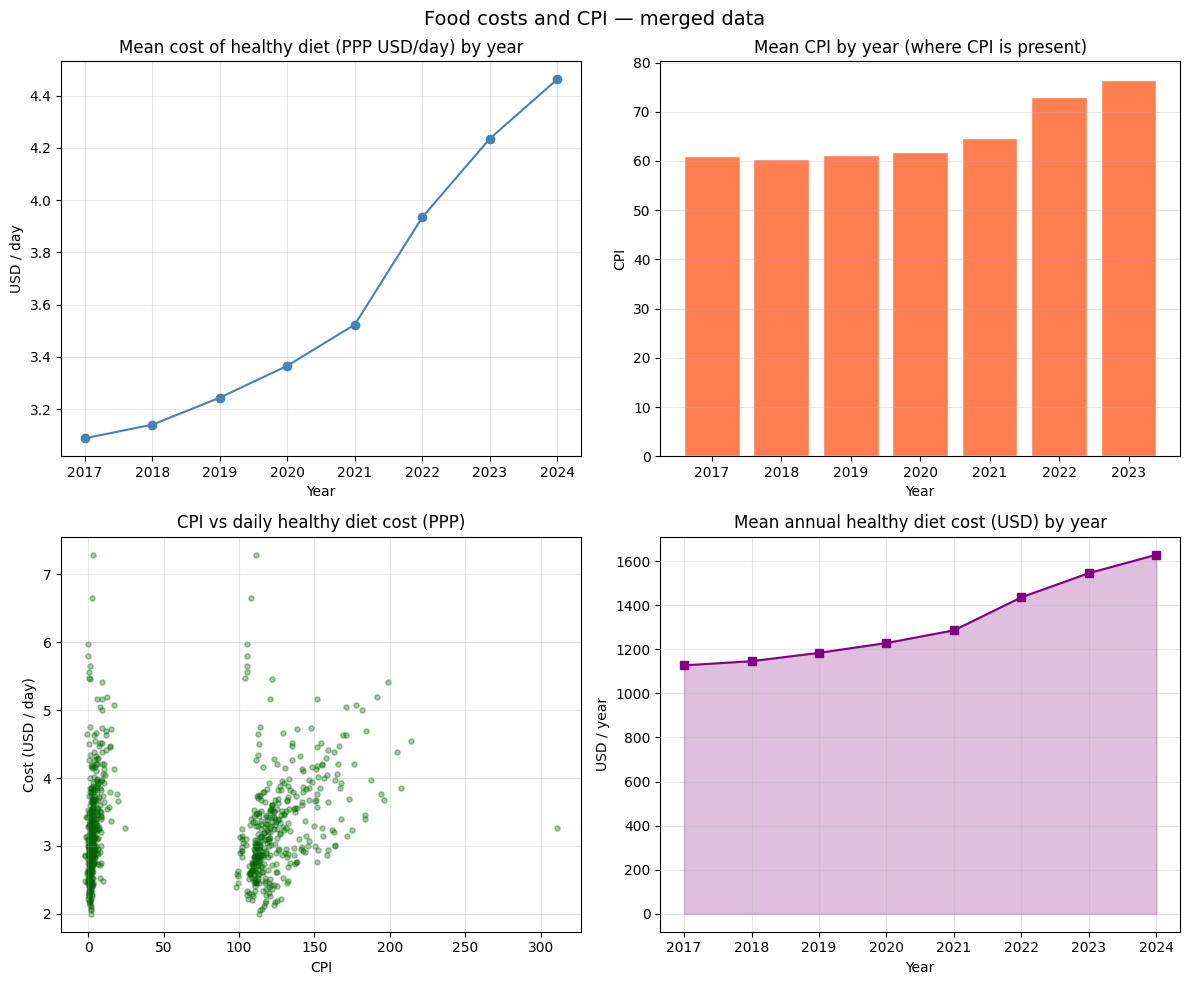

In [12]:
import matplotlib.pyplot as plt

# Visualizations for df_merged
plot_df = df_merged.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Food costs and CPI — merged data", fontsize=14)

#Mean daily healthy diet cost (PPP) by year
by_year_cost = plot_df.groupby("year")["cost_healthy_diet_ppp_usd"].mean()
axes[0, 0].plot(by_year_cost.index, by_year_cost.values, marker="o", color="steelblue")
axes[0, 0].set_title("Mean cost of healthy diet (PPP USD/day) by year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("USD / day")
axes[0, 0].grid(True, alpha=0.3)

#Mean CPI by year (rows with CPI only)
cpi_by_year = plot_df.dropna(subset=["cpi"]).groupby("year")["cpi"].mean()
if len(cpi_by_year):
    axes[0, 1].bar(
        cpi_by_year.index.astype(int),
        cpi_by_year.values,
        color="coral",
        edgecolor="white",
    )
axes[0, 1].set_title("Mean CPI by year (where CPI is present)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("CPI")
axes[0, 1].grid(True, axis="y", alpha=0.3)

#CPI vs daily healthy diet cost (both non-null)
scat = plot_df.dropna(subset=["cpi", "cost_healthy_diet_ppp_usd"])
axes[1, 0].scatter(
    scat["cpi"],
    scat["cost_healthy_diet_ppp_usd"],
    alpha=0.35,
    s=14,
    c="darkgreen",
)
axes[1, 0].set_title("CPI vs daily healthy diet cost (PPP)")
axes[1, 0].set_xlabel("CPI")
axes[1, 0].set_ylabel("Cost (USD / day)")
axes[1, 0].grid(True, alpha=0.3)

#Mean annual healthy diet cost (USD) by year
annual_by_year = plot_df.groupby("year")["annual_cost_healthy_diet_usd"].mean()
axes[1, 1].fill_between(
    annual_by_year.index, annual_by_year.values, alpha=0.25, color="purple"
)
axes[1, 1].plot(
    annual_by_year.index, annual_by_year.values, marker="s", color="purple"
)
axes[1, 1].set_title("Mean annual healthy diet cost (USD) by year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("USD / year")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# import sqlite3
# conn = sqlite3.connect('foodprices_data.db')
# cursor = conn.cursor()

# cursor.execute("""
#     CREATE TABLE IF NOT EXISTS FPtable (
#         id INTEGER PRIMARY KEY AUTOINCREMENT,
#         country TEXT,
#         year INTEGER,
#         cost_healthy_diet_ppp_usd FLOAT,    
#         annual_cost_healthy_diet_usd FLOAT,
#         cost_vegetables_ppp_usd FLOAT,
#         cost_fruits_ppp_usd FLOAT,
#         total_food_components_cost FLOAT,
#         continent TEXT
#     )
# """)

# # Convert DataFrame to list of tuples
# rows = list(df_combined[[ 'country', 'year', 'cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd', 'cost_vegetables_ppp_usd', 'cost_fruits_ppp_usd', 'total_food_components_cost', 'continent' ]].itertuples(index=False, name=None))

# cursor.execute("PRAGMA table_info(FPtable)")
# print(cursor.fetchall())

# # Insert all at once
# # cursor.executemany("""
# #     INSERT INTO FPtable (country, year, cost_healthy_diet_ppp_usd, annual_cost_healthy_diet_usd, cost_vegetables_ppp_usd, cost_fruits_ppp_usd, total_food_components_cost, continent)
# #     VALUES (?, ?, ?, ?, ?, ?, ?, ?)
# # """, rows)

# conn.commit()

# print(f"Inserted {len(rows)} rows in one batch!")

# cursor.execute("SELECT * FROM FPtable LIMIT 5")
# results = cursor.fetchall()
# for row in results:
#     print(row)  
# conn.close()

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('foodprices_data.db')
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS FPtable")

cursor.execute("""
    CREATE TABLE FPtable (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        country TEXT,
        year INTEGER,
        cost_healthy_diet_ppp_usd FLOAT,    
        annual_cost_healthy_diet_usd FLOAT,
        cost_vegetables_ppp_usd FLOAT,
        cost_fruits_ppp_usd FLOAT,
        total_food_components_cost FLOAT,
        continent TEXT,
        cpi FLOAT
    )
""")

# Verify schema BEFORE inserting
cursor.execute("PRAGMA table_info(FPtable)")
schema = cursor.fetchall()
print("Schema:", schema)
print("Number of columns:", len(schema))  # should be 10

# Prepare rows
columns = [
    'country',
    'year', 
    'cost_healthy_diet_ppp_usd',
    'annual_cost_healthy_diet_usd',
    'cost_vegetables_ppp_usd',
    'cost_fruits_ppp_usd',
    'total_food_components_cost',
    'continent',
    'cpi'
]
rows = list(df_merged[columns].itertuples(index=False, name=None))

# Insert data
cursor.executemany("""
    INSERT INTO FPtable (country, year, cost_healthy_diet_ppp_usd, annual_cost_healthy_diet_usd,
                         cost_vegetables_ppp_usd, cost_fruits_ppp_usd, total_food_components_cost, 
                         continent, cpi)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
""", rows)

conn.commit()
print(f"Inserted {len(rows)} rows!")

# Verify output
cursor.execute("SELECT * FROM FPtable LIMIT 5")
for row in cursor.fetchall():
    print(row)

conn.close()

Schema: [(0, 'id', 'INTEGER', 0, None, 1), (1, 'country', 'TEXT', 0, None, 0), (2, 'year', 'INTEGER', 0, None, 0), (3, 'cost_healthy_diet_ppp_usd', 'FLOAT', 0, None, 0), (4, 'annual_cost_healthy_diet_usd', 'FLOAT', 0, None, 0), (5, 'cost_vegetables_ppp_usd', 'FLOAT', 0, None, 0), (6, 'cost_fruits_ppp_usd', 'FLOAT', 0, None, 0), (7, 'total_food_components_cost', 'FLOAT', 0, None, 0), (8, 'continent', 'TEXT', 0, None, 0), (9, 'cpi', 'FLOAT', 0, None, 0)]
Number of columns: 10
Inserted 1751 rows!
(1, 'Albania', 2017, 3.04, 1109.6, None, None, None, 'Europe', None)
(2, 'Albania', 2018, 3.13, 1142.45, None, None, None, 'Europe', None)
(3, 'Albania', 2019, 3.32, 1211.8, None, None, None, 'Europe', None)
(4, 'Albania', 2020, 3.4, 1241.0, None, None, None, 'Europe', None)
(5, 'Albania', 2021, 3.49, 1273.85, 0.6, 0.77, 1.37, 'Europe', None)


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('foodprices_data.db')

# Read entire table into a DataFrame
df = pd.read_sql_query("SELECT * FROM FPtable", conn)

# Save to CSV
df.to_csv('foodprices_output.csv', index=False)

conn.close()
print(f"Exported {len(df)} rows to foodprices_output.csv")

Exported 1751 rows to foodprices_output.csv
